In [3]:
from google.cloud import storage

import os
import zipfile

import pandas as pd
import numpy as np

from torchvision import models,transforms

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from PIL import Image

from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def unzipArchive():
  client = storage.Client()

  bucketName = 'hammdata'
  bucket = client.get_bucket(bucketName)

  zipBlob = bucket.blob('archive.zip')
  zipBlob.download_to_filename('archive.zip')

  with zipfile.ZipFile('archive.zip', 'r') as zipRef:
      zipRef.extractall('archive')


In [5]:
def saveModel(model, filename):
  client = storage.Client()

  bucketName = 'hammdata'
  bucket = client.get_bucket(bucketName)

  torch.save(model.state_dict(), filename)

  blob = bucket.blob('models/' + filename)
  blob.upload_from_filename(filename)

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for classification tasks.
        Args:
            alpha (tensor): class weights (shape: [num_classes])
            gamma (float): focusing parameter
            reduction (str): 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [7]:
class HAMDataset(Dataset):
    def __init__(self, data, base_path='archive', label_col='target',img_col='image_id', transform=None):
        self.data = data
        self.labelCol = label_col
        self.imgCol = img_col
        self.transform = transform
        self.basePath = base_path
        self.classes = ["nv", "bkl", "df", "vasc", "mel", "bcc", "akiec"]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imageId = self.data.iloc[idx][self.imgCol]

        try:
            image = Image.open(self.basePath + "/HAM10000_images_part_1/" + imageId + ".jpg")
        except FileNotFoundError:
            try:
                image = Image.open(self.basePath + "/HAM10000_images_part_2/" + imageId + ".jpg")
            except FileExistsError:
                print("Could not find image for: ", imageId)

        label = torch.tensor(self.data.iloc[idx][self.labelCol])

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
unzipArchive()

In [64]:
EPOCHS = 25
imgSize = (224, 224)
lr = 5e-5
batchSize = 32
numClasses = 7

binary_map = {
  "nv": 0,
  "bkl": 1,
  "df": 2,
  "vasc": 3,
  "mel": 4,
  "bcc":  5,
  "akiec":  6
}

baseDir = 'archive'
normMeans = [0.76375736, 0.54612675, 0.57056087]
normStd = [0.13945314, 0.1524503,  0.16964808]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

bestAcc = 0
bestModel = None

Using device: cuda


In [65]:
  # read metadata
  metadata = pd.read_csv(baseDir + '/HAM10000_metadata.csv')
  metadata["target"] = metadata["dx"].map(binary_map)
  # metadata = metadata.groupby('lesion_id').sample(n=1, random_state=42).reset_index(drop=True)


In [66]:
transform = transforms.Compose([transforms.Resize(imgSize),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomVerticalFlip(),
                                transforms.RandomRotation(20),
                                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                transforms.ToTensor(),
                                transforms.Normalize(normMeans, normStd)])

valTestTransform = transforms.Compose([transforms.Resize(imgSize),
                                          transforms.ToTensor(),
                                          transforms.Normalize(normMeans, normStd)])

trainValData, testData = train_test_split(metadata, test_size=0.2, random_state=42)
trainData, valData = train_test_split(trainValData, test_size=0.2, random_state=42)

trainDataset = HAMDataset(trainData, transform=transform)
valDataset = HAMDataset(valData, transform=valTestTransform)
testDataset = HAMDataset(testData, transform=valTestTransform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=batchSize)
testLoader = DataLoader(testDataset, batch_size=batchSize)

In [67]:
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, numClasses)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, numClasses)
)


model = model.to(device)



criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

#class_count = metadata['target'].value_counts()
#total = class_count.sum()
#class_weights = total / (class_count * len(class_count))
#class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)
#criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [68]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(trainLoader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # scheduler.step()
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(trainLoader):.4f} | Accuracy: {100 * correct / total:.2f}%")

    # 🎯 Training summary
    train_loss = running_loss / len(trainLoader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    # val_preds, val_labels = evaluate_model(model, valLoader, device)

    model.eval()
    valCorrect = 0
    valTotal = 0

    with torch.no_grad():
        for images, labels in valLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            valTotal += labels.size(0)
            valCorrect += (predicted == labels).sum().item()

    valAcc = 100 * valCorrect / valTotal
    print(f"Validation Accuracy: {100 * valCorrect / valTotal:.2f}%")

    # 💾 Save best model by F1
    if valAcc > bestAcc:
        bestAcc = valAcc
        bestModel = model
        torch.save(model.state_dict(), "best_val1_dup_model.pt")
        print(f"💾 Saved new best model")

Epoch 1/25: 100%|██████████| 201/201 [01:34<00:00,  2.13it/s, acc=72.1, loss=0.275]


Epoch 1 | Loss: 0.7944 | Accuracy: 72.09%
✅ Training Loss: 0.7944 | Accuracy: 72.09%
Validation Accuracy: 78.23%
💾 Saved new best model


Epoch 2/25: 100%|██████████| 201/201 [01:34<00:00,  2.13it/s, acc=80, loss=0.513]


Epoch 2 | Loss: 0.5707 | Accuracy: 79.95%
✅ Training Loss: 0.5707 | Accuracy: 79.95%
Validation Accuracy: 81.10%
💾 Saved new best model


Epoch 3/25: 100%|██████████| 201/201 [01:34<00:00,  2.13it/s, acc=83.1, loss=0.429]


...

Epoch 23 | Loss: 0.0807 | Accuracy: 97.08%
✅ Training Loss: 0.0807 | Accuracy: 97.08%
Validation Accuracy: 87.52%
💾 Saved new best model


Epoch 24/25: 100%|██████████| 201/201 [01:34<00:00,  2.13it/s, acc=97.3, loss=0.199]


Epoch 24 | Loss: 0.0846 | Accuracy: 97.25%
✅ Training Loss: 0.0846 | Accuracy: 97.25%
Validation Accuracy: 87.09%


Epoch 25/25: 100%|██████████| 201/201 [01:34<00:00,  2.13it/s, acc=97.2, loss=0.251]


Epoch 25 | Loss: 0.0818 | Accuracy: 97.21%
✅ Training Loss: 0.0818 | Accuracy: 97.21%
Validation Accuracy: 86.84%


In [30]:
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Evaluation Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels

In [45]:
  model.eval()
  valCorrect = 0
  valTotal = 0

  with torch.no_grad():
      for images, labels in valLoader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs, 1)
          valTotal += labels.size(0)
          valCorrect += (predicted == labels).sum().item()

  print(f"Validation Accuracy: {100 * valCorrect / valTotal:.2f}%")

Validation Accuracy: 84.78%


In [69]:
    # After training is done:
    valPreds, valLabels = evaluate_model(bestModel, valLoader, device)

✅ Evaluation Accuracy: 86.84%


In [70]:
    testPreds, testLabels = evaluate_model(bestModel, testLoader, device)

✅ Evaluation Accuracy: 86.62%


In [71]:
    # Print classification report
    print(classification_report(valLabels, valPreds, target_names=trainDataset.classes))
    print(classification_report(testPreds, testLabels, target_names=trainDataset.classes))


              precision    recall  f1-score   support

          nv       0.93      0.94      0.94      1059
         bkl       0.78      0.74      0.76       192
          df       1.00      0.36      0.53        14
        vasc       1.00      1.00      1.00        17
         mel       0.74      0.63      0.68       190
         bcc       0.78      0.88      0.83        89
       akiec       0.46      0.74      0.57        42

    accuracy                           0.87      1603
   macro avg       0.81      0.75      0.76      1603
weighted avg       0.87      0.87      0.87      1603

              precision    recall  f1-score   support

          nv       0.94      0.94      0.94      1343
         bkl       0.70      0.77      0.73       206
          df       0.46      0.81      0.59        16
        vasc       1.00      0.81      0.89        26
         mel       0.65      0.72      0.68       204
         bcc       0.94      0.78      0.85       112
       akiec       0.72 

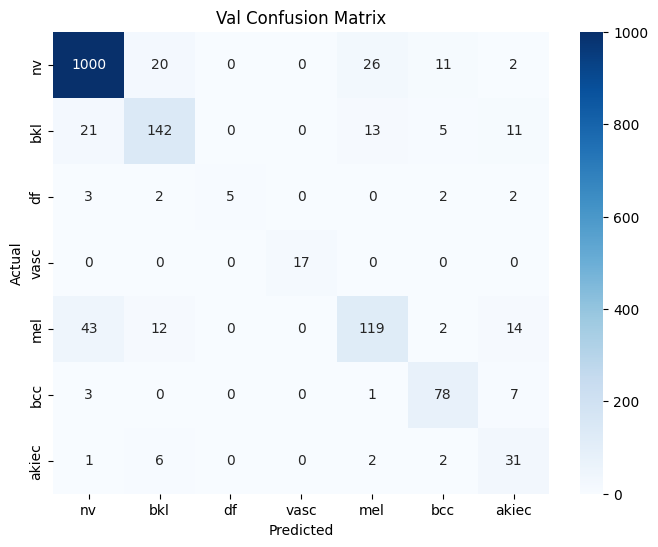

In [72]:
    # Confusion matrix
    cm = confusion_matrix(valLabels, valPreds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=trainDataset.classes, yticklabels=trainDataset.classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Val Confusion Matrix')
    plt.show()

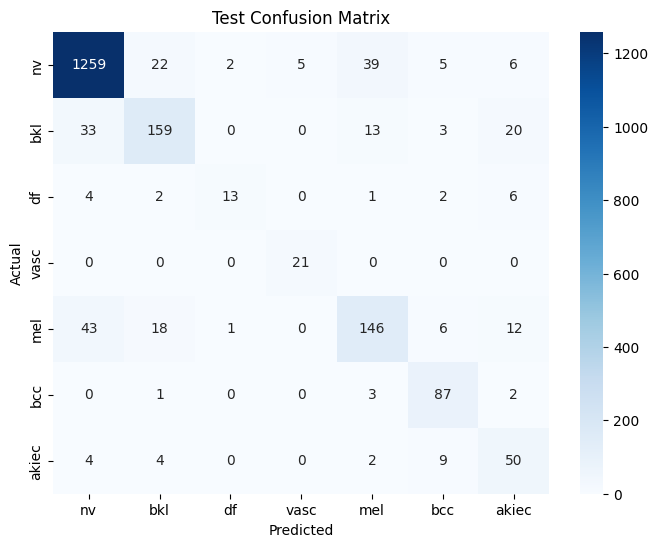

In [73]:
    cm = confusion_matrix(testLabels, testPreds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=trainDataset.classes, yticklabels=trainDataset.classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Test Confusion Matrix')
    plt.show()

In [74]:
saveModel(bestModel, 'best_val_dup_model_87.pt')

In [62]:
bestModel

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 